<a href="https://colab.research.google.com/github/cemilkaracam/Haar-Wavelet-Regularized-Approximation-of-Discontinuous-Functions/blob/main/Numerical_Result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

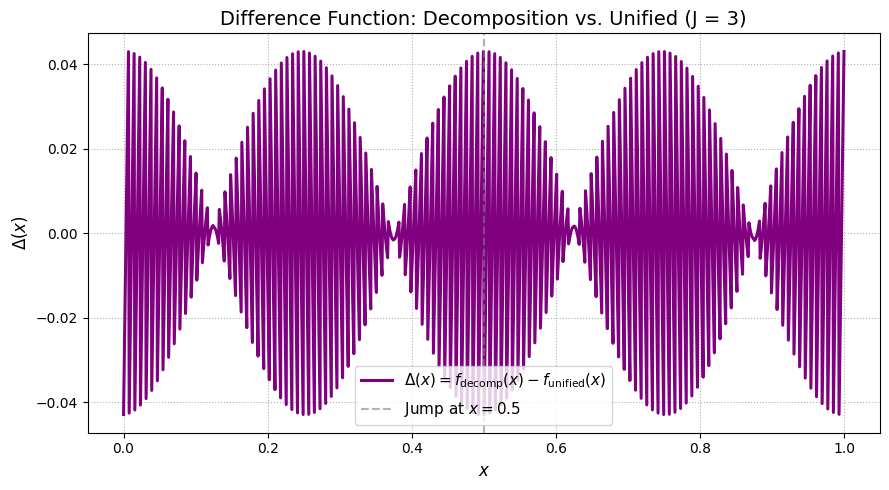

In [ ]:
# Haar Regularization Difference Plot: sin(4πx) + χ[0.5,1](x)
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Domain
x = np.linspace(0, 1, 1024)

# Function components
f_sin = np.sin(4 * np.pi * x)
f_jump = (x >= 0.5).astype(float)
f_true = f_sin + f_jump

# Haar regularization function
def haar_regularize(signal, level=3):
    coeffs = pywt.wavedec(signal, 'haar', level=level)
    coeffs_trunc = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
    return pywt.waverec(coeffs_trunc, 'haar')[:len(signal)]

# Unified Haar: apply to full function
f_unified = haar_regularize(f_true, level=3)

# Decomposition Haar: apply only to discontinuous part
f_jump_reg = haar_regularize(f_jump, level=3)
f_decomp = f_sin + f_jump_reg

# Difference function
delta = f_decomp - f_unified

# Visualization
plt.figure(figsize=(9, 5))
plt.plot(x, delta, color='purple', linewidth=2.2,
         label=r'$\Delta(x) = f_{\rm decomp}(x) - f_{\rm unified}(x)$')
plt.axvline(x=0.5, linestyle='--', color='gray', alpha=0.6,
            label='Jump at $x = 0.5$')
plt.xlabel('$x$', fontsize=12)
plt.ylabel(r'$\Delta(x)$', fontsize=12)
plt.title('Difference Function: Decomposition vs. Unified (J = 3)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()
